In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5
f(4.0)

37.0

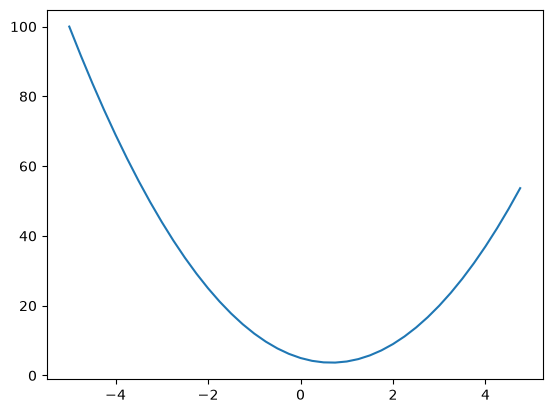

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.001
x = 2
dydx = (f(x + h) - f(x)) /(h)
print(dydx)

8.003000000000426


In [6]:
h = 0.0001
a = 2
b = 3
c = 10
d1 = a*b + c
a+=h
d2 = a*b + c
dydx = (d2 - d1) / h
print(dydx)


3.0000000000285354


In [ ]:
from turtle import backward


class Value:
    def __init__(self, data , _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), _op='+')
        def _backward():
            self.grad = other.grad * 1.0
            other.grad = self.grad * 1.0
            out.backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op='*')
        def backward():
            self.grad = other.grad * other.data
            other.grad = self.grad * self.data
            out._backward = backward
        return out
    def tanh(self):
        x = self.data
        t = math.exp(2*x) - 1 / (math.exp(2*x) + 1)
        out = Value(t, (self,), _op='tanh')
        def _backward():
            self.grad = (1 - self.data**2) * self.grad
            out._backward = _backward
        return out

a   = Value(2.0)
b   = Value(-3.0)
c   = Value(10.0)
d= a*b + c
print(d._prev)
print(d._op)

{Value(data=-6.0), Value(data=10.0)}
+


In [16]:
h = 0.0001 

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

e = a*b
d = e+c
f = Value(-2.0)

L = d*f
L1 = L.data

a = Value(2.0 )
b = Value(-3.0)
c = Value(10.0)
b.data += h
e   = a*b
d = e+c
# d.data += h
f = Value(-2.0 )
L = d*f
L2 = L.data

dydx = (L2 - L1) / h
print(dydx)

-4.000000000008441


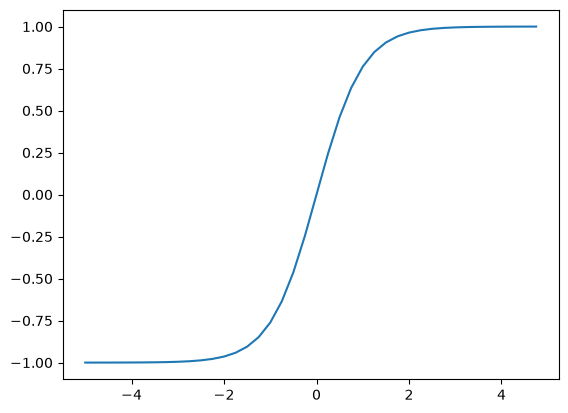

In [ ]:
o._bac